In [16]:
import numpy as np
import pandas as pd
import os 
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error

# Set up plotting style
plt.rcParams.update({'font.size': 12})
sns.set_style("whitegrid")


In [17]:
# Configuration for paw speed
base_path = "/media/lenny-aharon/T7/ibl-mouse/ibl-mouse_neural-activity/results"
# eid = "15b69921-d471-4ded-8814-2adad954bcd8"    
# eid = "15763234-d21e-491f-a01b-1238eb96d389" 
# eid = "aad23144-0e52-4eac-80c5-c4ee2decb198"
# eid = "9b528ad0-4599-4a55-9148-96cc1d93fb24"
# eid = "4b00df29-3769-43be-bb40-128b1cba6d35"
# eid = "0841d188-8ef2-4f20-9828-76a94d5343a4"
# eid = "f312aaec-3b6f-44b3-86b4-3a0c119c0438"
eid = "5c0c560e-9e1f-45e9-b66e-e4ee7855be84"  # Updated to the session with paw speed data

# target = "lightning-pose-left-pawL-speed"  # The paw speed target we decoded
target = "lightning-pose-pawL-3d-speed"  # The paw speed target we decoded
model = "linear"
# model = "reduced_rank"

# Define the two pose models to compare
pose_models = ["MVT_3d_aug_patch_median", "resnet50_median"]
# pose_models = ["resnet50_median"]



In [18]:
import os
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

def load_session_results(base_path, eid, target, pose_models, model_method="linear"):
    """
    Loads cross-validation results for multiple pose models.
    Automatically detects and flattens all coordinate and variance data,
    including 3D triangulation and multi-view keys.
    """
    results = {}
    
    for pose_model in pose_models:
        results_path = f"{base_path}/{eid}/{target}/{pose_model}/{model_method}/all/{eid}_cv.npy"
        
        if not os.path.exists(results_path):
            print(f"Warning: Results not found at {results_path}")
            continue
            
        print(f"\n{'='*40}")
        print(f"Loading: {pose_model}")
        
        # Load the data dictionary
        data = np.load(results_path, allow_pickle=True).item()
        
        # 1. Core Speed Data
        test_y = data['all_test_y']
        test_pred = data['all_test_pred']
        y_flat = test_y.flatten()
        pred_flat = test_pred.flatten()
                
        # 2. Initialize result container for this model
        res = {
            'test_y': test_y,
            'test_pred': test_pred,
            'y_flattened': y_flat,
            'pred_flattened': pred_flat,
            'test_metric': data['overall_metric'],
            'r2': r2_score(y_flat, pred_flat),
            'mse': mean_squared_error(y_flat, pred_flat),
            'correlation': np.corrcoef(y_flat, pred_flat)[0, 1],
            # Mapping Info
            'test_frame_indices': data.get('all_test_frame_indices'),
            'test_original_trial_ids': data.get('all_test_original_trial_indices')
        }
        
        # 3. Dynamic Ensemble/Coordinate extraction
        # This will automatically pick up: x_ens_var, left_x_ens_var, x_3d, etc.
        ens_data = data.get('all_test_ens_vars', {})
        for key, val in ens_data.items():
            if val is not None:
                res[key] = val
                res[f"{key}_flattened"] = val.flatten()
        
        # Load all available ensemble/coordinate data
        ens_data = data.get('all_test_ens_vars', {})
        for key, val in ens_data.items():
            if val is not None:
                res[key] = val
                res[f"{key}_flattened"] = val.flatten()
        
        # --- CALCULATE UNIFIED AVERAGE VARIANCE ---
        # CASE A: 2D Target (has x_ens_var and y_ens_var)
        if 'x_ens_var' in res and 'y_ens_var' in res:
            avg_var = (res['x_ens_var'] + res['y_ens_var']) / 2
            res['avg_ens_var_flattened'] = avg_var.flatten()
            
        # CASE B: 3D Target (has left_x_ens_var, right_x_ens_var, etc.)
        elif 'left_x_ens_var' in res and 'right_x_ens_var' in res:
            # Average across all 4 components (Left X, Left Y, Right X, Right Y)
            all_vars = [res['left_x_ens_var'], res['left_y_ens_var'], 
                        res['right_x_ens_var'], res['right_y_ens_var']]
            avg_var = sum(all_vars) / 4
            res['avg_ens_var_flattened'] = avg_var.flatten()

        results[pose_model] = res
        
        # Print summary
        print(f"  Target: {target}")
        print(f"  Session: {eid}")
        print(f"  Trials: {len(res['test_original_trial_ids']) if res['test_original_trial_ids'] is not None else 'Unknown'}")
        print(f"  R² (flattened): {res['r2']:.3f}")
        
        # List what was extracted (for debugging)
        extracted_keys = [k for k in ens_data.keys() if ens_data[k] is not None]
        if extracted_keys:
            print(f"  Extracted vars: {', '.join(extracted_keys)}")

    return results



results = load_session_results(base_path, eid, target, pose_models,model_method=model)


Loading: resnet50_median
  Target: lightning-pose-pawL-3d-speed
  Session: 5c0c560e-9e1f-45e9-b66e-e4ee7855be84
  Trials: 315
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords



--- MVT_3d_aug_patch_median Per-Bin R² Summary ---


  First bin (0ms):  0.0173
  Middle bin (1s):  0.2047
  Last bin (2s):    0.0086
  Mean of all bins: 0.0857

--- resnet50_median Per-Bin R² Summary ---
  First bin (0ms):  0.0209
  Middle bin (1s):  0.2036
  Last bin (2s):    0.0044
  Mean of all bins: 0.0900


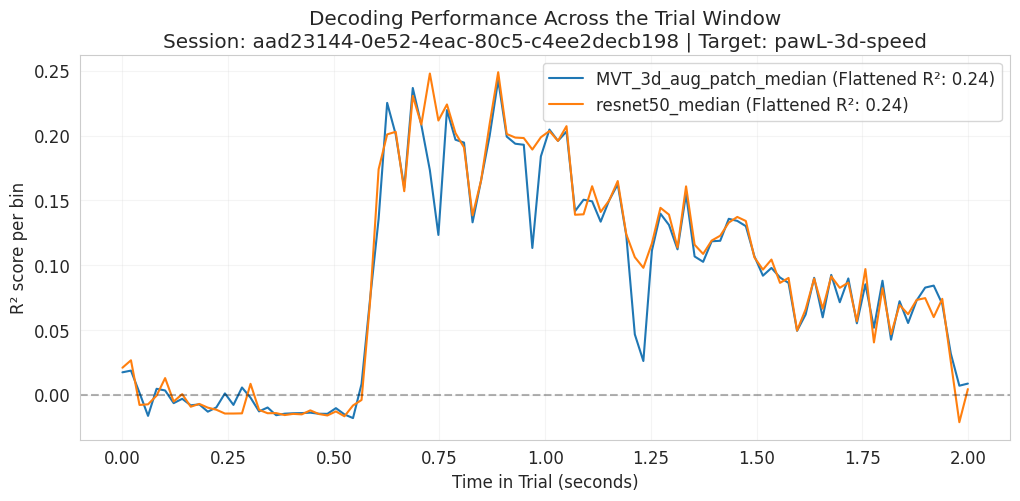

In [129]:
def analyze_per_bin_performance(results, pose_models):
    """
    Calculates and prints/plots R^2 for every time bin (0-100) for each model.
    """
    plt.figure(figsize=(12, 5))
    
    for model_name in pose_models:
        res = results[model_name]
        y_true = res['test_y']     # Shape: [n_trials, n_bins]
        y_pred = res['test_pred']   # Shape: [n_trials, n_bins]
        
        n_bins = y_true.shape[1]
        bin_r2s = []
        
        print(f"\n--- {model_name} Per-Bin R² Summary ---")
        for b in range(n_bins):
            # Calculate R2 for this specific bin across all trials
            r2 = r2_score(y_true[:, b], y_pred[:, b])
            bin_r2s.append(r2)
        
        # Print a few example bins
        print(f"  First bin (0ms):  {bin_r2s[0]:.4f}")
        print(f"  Middle bin (1s):  {bin_r2s[n_bins//2]:.4f}")
        print(f"  Last bin (2s):    {bin_r2s[-1]:.4f}")
        print(f"  Mean of all bins: {np.mean(bin_r2s):.4f}")
        
        # Plot the curve
        plt.plot(np.linspace(0, 2, n_bins), bin_r2s, label=f"{model_name} (Flattened R²: {res['r2']:.2f})")

    plt.axhline(0, color='black', linestyle='--', alpha=0.3)
    plt.xlabel("Time in Trial (seconds)")
    plt.ylabel("R² score per bin")
    target_without = target.replace("lightning-pose-", "")
    plt.title(f"Decoding Performance Across the Trial Window\nSession: {eid} | Target: {target_without}")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

# Run the analysis
analyze_per_bin_performance(results, pose_models)

In [130]:
results

{'MVT_3d_aug_patch_median': {'test_y': array([[0.00617299, 0.00300008, 0.00213597, ..., 0.00557729, 0.00383656,
          0.00247863],
         [0.00368628, 0.00422591, 0.00162394, ..., 0.05012336, 0.00509919,
          0.00440425],
         [0.00613698, 0.00330121, 0.00188134, ..., 0.00258215, 0.00096597,
          0.00541732],
         ...,
         [0.00358026, 0.00122328, 0.00150189, ..., 0.09308526, 0.20552046,
          0.21385394],
         [0.00207993, 0.00120248, 0.00142161, ..., 0.00406471, 0.00139523,
          0.00164339],
         [0.00419004, 0.0059055 , 0.006559  , ..., 0.00822367, 0.00373739,
          0.00318806]]),
  'test_pred': array([[ 0.08625329,  0.03729173,  0.06627315, ...,  0.09227082,
           0.04078836,  0.14465502],
         [-0.02176597,  0.00181086, -0.00630877, ...,  0.18148536,
           0.29040144,  0.03072365],
         [-0.00250842,  0.01240421,  0.01409871, ...,  0.16573815,
           0.2713203 ,  0.40518823],
         ...,
         [ 0.0316686

In [131]:
# # Store results for each pose model
# results = {}

# for pose_model in pose_models:
#     results_path = f"{base_path}/{eid}/{target}/{pose_model}/{model}/all/{eid}_cv.npy"
#     print(f"\n{'='*60}")
#     print(f"Loading: {pose_model}")
#     print(f"Path: {results_path}")
    
#     # Load the data
#     data = np.load(results_path, allow_pickle=True).item()
    
#     # Extract existing data
#     test_y = data['all_test_y']
#     test_pred = data['all_test_pred']
#     test_metric = data['overall_metric']
    
#     # NEW: Extract trial and frame mapping info
#     test_frame_indices = data.get('all_test_frame_indices')
#     test_original_trial_ids = data.get('all_test_original_trial_indices')
    
#     # Extract ensemble variances and coordinates
#     ens_data = data.get('all_test_ens_vars', {})
#     test_ens_x = ens_data.get('x_ens_var')
#     test_ens_y = ens_data.get('y_ens_var')
#     test_x_coords = ens_data.get('x_coords')
#     test_y_coords = ens_data.get('y_coords')
#     test_x_3d = ens_data.get('x_3d')
#     test_y_3d = ens_data.get('y_3d')
#     test_z_3d = ens_data.get('z_3d')
    
#     # Flatten for continuous traces
#     y_flattened = test_y.flatten()
#     pred_flattened = test_pred.flatten()
    
#     # Flatten new fields if they exist
#     ens_x_flat = test_ens_x.flatten() if test_ens_x is not None else None
#     ens_y_flat = test_ens_y.flatten() if test_ens_y is not None else None
#     x_coords_flat = test_x_coords.flatten() if test_x_coords is not None else None
#     y_coords_flat = test_y_coords.flatten() if test_y_coords is not None else None
#     x_3d_flat = test_x_3d.flatten() if test_x_3d is not None else None
#     y_3d_flat = test_y_3d.flatten() if test_y_3d is not None else None
#     z_3d_flat = test_z_3d.flatten() if test_z_3d is not None else None
    
#     # Calculate metrics
#     correlation = np.corrcoef(y_flattened, pred_flattened)[0, 1]
#     r2 = r2_score(y_flattened, pred_flattened)
#     mse = mean_squared_error(y_flattened, pred_flattened)
    
#     # Store results
#     results[pose_model] = {
#         'test_y': test_y,
#         'test_pred': test_pred,
#         'test_frame_indices': test_frame_indices,        # Added Mapping
#         'test_original_trial_ids': test_original_trial_ids, # Added Mapping
#         'test_ens_x': test_ens_x,
#         'test_ens_y': test_ens_y,
#         'test_x_coords': test_x_coords,
#         'test_y_coords': test_y_coords,
#         'test_x_3d': test_x_3d,
#         'test_y_3d': test_y_3d,
#         'test_z_3d': test_z_3d,
#         'y_flattened': y_flattened,
#         'pred_flattened': pred_flattened,
#         'ens_x_flattened': ens_x_flat,
#         'ens_y_flattened': ens_y_flat,
#         'x_coords_flattened': x_coords_flat,
#         'y_coords_flattened': y_coords_flat,
#         'x_3d_flattened': x_3d_flat,
#         'y_3d_flattened': y_3d_flat,
#         'z_3d_flattened': z_3d_flat,
#         'test_metric': test_metric,
#         'r2': r2,
#         'mse': mse,
#         'correlation': correlation
#     }
    
#     print(f"Data shapes: test_y={test_y.shape}, test_pred={test_pred.shape}")
#     if test_frame_indices is not None:
#         print(f"Trial mapping loaded: {len(test_original_trial_ids)} trials")
#         print(f"Example: First trial is Session #{test_original_trial_ids[0]}, Video frames {test_frame_indices[0]}")
    
#     print(f"R² across timestamps (from file): {test_metric:.3f}")
#     print(f"R² (computed): {r2:.3f}")
#     print(f"MSE: {mse:.3f}")
#     print(f"Correlation: {correlation:.3f}")

In [132]:
# results['MVT_patch_masking_median']

In [133]:
# Define colors for each pose model
# Darker color for pose model (ground truth), lighter for decoded prediction
colors = {
    # 'MVT_patch_masking_median': {
    #     'pose': '#1f77b4',      # Dark blue
    #     'decoded': '#aec7e8'    # Light blue
    # },
    'MVT_3d_aug_patch_median': {
        'pose': '#1f77b4',      # Dark blue
        'decoded': '#aec7e8'    # Light blue
    },
    'resnet50_median': {
        'pose': '#d62728',      # Dark red
        'decoded': '#ff9896'    # Light red/pink
    }
}

In [134]:
# def plot_pose_results(results, pose_models, colors, eid, 
#                       plots_to_show=None, 
#                       start_time=0, 
#                       end_time=800, 
#                       sampling_rate=0.02,
#                       target=target):
#     """
#     Flexible plotting function with dynamic time-axis calculation.
#     """
#     plot_config = {
#         'speed': {'label': 'Speed (pix/s)', 'data_key': 'y_flattened'},
#         'avg_ens_var': {'label': 'Avg Ens Var', 'data_key': None},
#         'x_coords': {'label': 'X-Coords', 'data_key': 'x_coords_flattened'},
#         'y_coords': {'label': 'Y-Coords', 'data_key': 'y_coords_flattened'},
#         'x_3d': {'label': 'X-3D', 'data_key': 'x_3d_flattened'},
#         'y_3d': {'label': 'Y-3D', 'data_key': 'y_3d_flattened'},
#         'z_3d': {'label': 'Z-3D', 'data_key': 'z_3d_flattened'}
#     }

#     if plots_to_show is None:
#         plots_to_show = list(plot_config.keys())

#     num_plots = len(plots_to_show)
#     fig, axes = plt.subplots(num_plots, 1, figsize=(14, 3 * num_plots), sharex=True)
    
#     if num_plots == 1:
#         axes = [axes]

#     for i, plot_key in enumerate(plots_to_show):
#         ax = axes[i]
#         config = plot_config[plot_key]
        
#         for pose_model in pose_models:
#             res = results[pose_model]
#             color_pose = colors[pose_model]['pose']
            
#             if plot_key == 'speed':
#                 ax.plot(res['y_flattened'][start_time:end_time], 
#                         color=color_pose, linewidth=2, label=f"Pose: {pose_model}")
#                 ax.plot(res['pred_flattened'][start_time:end_time], 
#                         color=colors[pose_model]['decoded'], linewidth=1.5, 
#                         label=f"Decoded: {pose_model} (R²={res['r2']:.3f})", alpha=0.8)
            
#             elif plot_key == 'avg_ens_var':
#                 if res.get('ens_x_flattened') is not None:
#                     avg_var = (res['ens_x_flattened'] + res['ens_y_flattened']) / 2
#                     ax.plot(avg_var[start_time:end_time], color=color_pose, label=f"{pose_model}")
            
#             else:
#                 data = res.get(config['data_key'])
#                 if data is not None:
#                     ax.plot(data[start_time:end_time], color=color_pose, label=f"{pose_model}")

#         ax.set_ylabel(config['label'], fontsize=11)
#         ax.legend(fontsize=8, loc='upper right', ncol=2)
#         ax.grid(True, alpha=0.2)

#     # --- DYNAMIC X-AXIS CALCULATION ---
#     # Calculate number of frames being shown
#     duration_frames = end_time - start_time
    
#     # Create 9 ticks across the visible range
#     # These represent the local indices [0, duration_frames]
#     tick_indices = np.linspace(0, duration_frames, 9)
    
#     # Calculate actual timestamps in seconds for labels
#     # (Local index + global start_time) * sampling_rate
#     tick_labels = [(start_time + idx) * sampling_rate for idx in tick_indices]
    
#     axes[-1].set_xticks(tick_indices)
#     axes[-1].set_xticklabels([f"{t:.2f}s" for t in tick_labels])
#     axes[-1].set_xlabel("Time (seconds)", fontsize=12)
#     lightning_pose_without = target.replace("lightning-pose-", "")
#     axes[0].set_title(f"{lightning_pose_without}- Session: {eid} | Window: {start_time}-{end_time} frames", fontsize=14)
#     plt.tight_layout()
#     return fig, axes
# # plots_to_show = ['speed', 'avg_ens_var', 'x_coords', 'y_coords', 'x_3d', 'y_3d', 'z_3d']

# # plots_to_show = ['speed', 'avg_ens_var', 'x_3d', 'y_3d', 'z_3d']
# plots_to_show = ['speed', 'x_3d', 'y_3d', 'z_3d']

# plot_pose_results(results, pose_models, colors, eid, plots_to_show)

(<Figure size 1400x1500 with 5 Axes>,
 array([<Axes: title={'center': 'pawL-3d-speed- Session: aad23144-0e52-4eac-80c5-c4ee2decb198 | Window: 0-800'}, ylabel='Speed (pix/s)'>,
        <Axes: ylabel='Avg Ensemble Var'>, <Axes: ylabel='X-3D'>,
        <Axes: ylabel='Y-3D'>,
        <Axes: xlabel='Time (seconds) & Video Frame Index', ylabel='Z-3D'>],
       dtype=object))

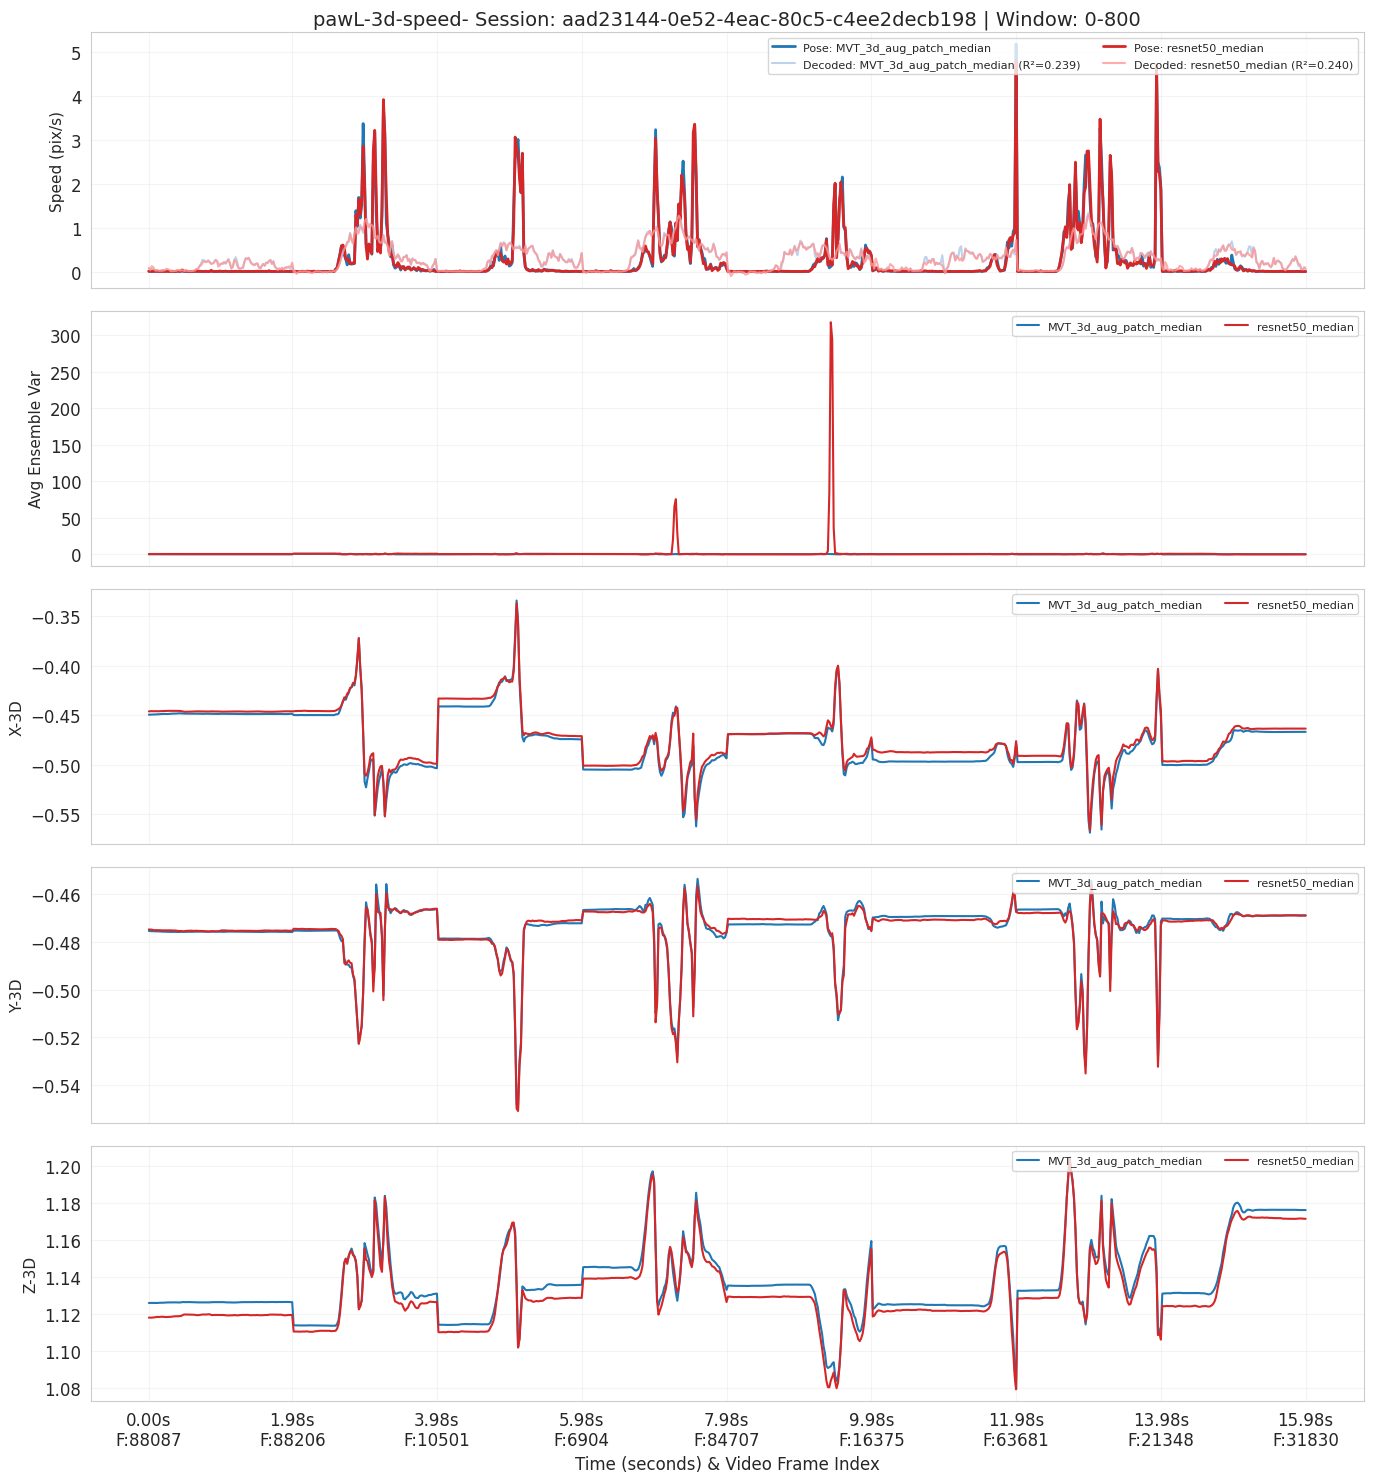

In [ ]:
def plot_pose_results(results, pose_models, colors, eid, 
                      plots_to_show=None, 
                      start_time=0, 
                      end_time=800, 
                      sampling_rate=0.02,
                      target=target):
    
    # --- 1. LOAD MAPPING METADATA ---
    common_data_path = Path("/media/lenny-aharon/T7/ibl-mouse/ibl-mouse_neural-activity/ibl_aligned") / eid
    alignment_info = np.load(common_data_path / "alignment_info.npy", allow_pickle=True).item()
    trial_intervals = alignment_info["trial_intervals"] 
    timestamp_file = Path("/media/lenny-aharon/T7/ibl-mouse/timestamps") / f"_ibl_leftCamera.times.{eid}.npy"
    frame_times = np.load(timestamp_file)
    
    orig_trial_ids = results[pose_models[0]]['test_original_trial_ids']
    trial_len_bins = 100 

    # --- 2. UPDATED PLOT CONFIG ---
    # We map the keys we added in the loader to user-friendly labels
    plot_config = {
        'speed': {'label': 'Speed (pix/s)', 'data_key': 'y_flattened'},
        'avg_var': {'label': 'Avg Ensemble Var', 'data_key': 'avg_ens_var_flattened'}, # <--- USE THIS
        'x_3d': {'label': 'X-3D', 'data_key': 'x_3d_flattened'},
        'y_3d': {'label': 'Y-3D', 'data_key': 'y_3d_flattened'},
        'z_3d': {'label': 'Z-3D', 'data_key': 'z_3d_flattened'}
    }

    if plots_to_show is None:
        plots_to_show = list(plot_config.keys())

    num_plots = len(plots_to_show)
    fig, axes = plt.subplots(num_plots, 1, figsize=(14, 3 * num_plots), sharex=True)
    if num_plots == 1: axes = [axes]

    for i, plot_key in enumerate(plots_to_show):
        ax = axes[i]
        config = plot_config.get(plot_key, {'label': plot_key, 'data_key': f"{plot_key}_flattened"})
        
        for pose_model in pose_models:
            res = results[pose_model]
            color_pose = colors[pose_model]['pose']
            
            if plot_key == 'speed':
                ax.plot(res['y_flattened'][start_time:end_time], color=color_pose, linewidth=2, label=f"Pose: {pose_model}")
                ax.plot(res['pred_flattened'][start_time:end_time], color=colors[pose_model]['decoded'], linewidth=1.5, 
                        label=f"Decoded: {pose_model} (R²={res['r2']:.3f})", alpha=0.8)
            else:
                # General plotting for all coordinate and variance keys
                data = res.get(config['data_key'])
                if data is not None:
                    ax.plot(data[start_time:end_time], color=color_pose, label=f"{pose_model}")

        ax.set_ylabel(config['label'], fontsize=11)
        ax.legend(fontsize=8, loc='upper right', ncol=2)
        ax.grid(True, alpha=0.2)

    # --- 3. DYNAMIC X-AXIS WITH VIDEO FRAMES ---
    duration_frames = end_time - start_time
    tick_indices = np.linspace(0, duration_frames - 1, 9, dtype=int)
    time_labels, frame_labels = [], []

    for idx in tick_indices:
        global_idx = start_time + idx
        time_labels.append(f"{(global_idx * sampling_rate):.2f}s")
        
        # trial_idx_in_test = global_idx // trial_len_bins
        # bin_within_trial = global_idx % trial_len_bins
        
        # if trial_idx_in_test < len(orig_trial_ids):
        #     orig_id = orig_trial_ids[trial_idx_in_test]
        #     bin_time = trial_intervals[orig_id][0] + (bin_within_trial * sampling_rate)
        #     video_frame = np.searchsorted(frame_times, bin_time)
        #     frame_labels.append(f"F:{video_frame}")
        # else:
        #     frame_labels.append("")

         # --- Inside the dynamic X-axis loop ---
        trial_idx_in_test = global_idx // trial_len_bins
        bin_within_trial = global_idx % trial_len_bins
        
        # ADD THIS CHECK: Ensure orig_trial_ids is not None
        if orig_trial_ids is not None and trial_idx_in_test < len(orig_trial_ids):
            orig_id = orig_trial_ids[trial_idx_in_test]
            bin_time = trial_intervals[orig_id][0] + (bin_within_trial * sampling_rate)
            video_frame = np.searchsorted(frame_times, bin_time)
            frame_labels.append(f"F:{video_frame}")
        else:
            # Fallback if mapping is missing
            frame_labels.append("")

    axes[-1].set_xticks(tick_indices)
    axes[-1].set_xticklabels([f"{t}\n{f}" for t, f in zip(time_labels, frame_labels)])
    axes[-1].set_xlabel("Time (seconds) & Video Frame Index", fontsize=12)
    
    lightning_pose_without = target.replace("lightning-pose-", "")
    axes[0].set_title(f"{lightning_pose_without}- Session: {eid} | Window: {start_time}-{end_time}", fontsize=14)
    plt.tight_layout()
    return fig, axes

# --- Example of showing the new average variance plots ---
plots_to_show = ['speed', 'avg_var','x_3d', 'y_3d', 'z_3d']
plot_pose_results(results, pose_models, colors, eid, plots_to_show, start_time=800, end_time=1600)

(<Figure size 1400x1500 with 5 Axes>,
 array([<Axes: title={'center': 'pawL-3d-speed- Session: aad23144-0e52-4eac-80c5-c4ee2decb198 | Window: 1100-1200'}, ylabel='Speed (pix/s)'>,
        <Axes: ylabel='Avg Ensemble Var'>, <Axes: ylabel='X-3D'>,
        <Axes: ylabel='Y-3D'>,
        <Axes: xlabel='Time (seconds) & Video Frame Index', ylabel='Z-3D'>],
       dtype=object))

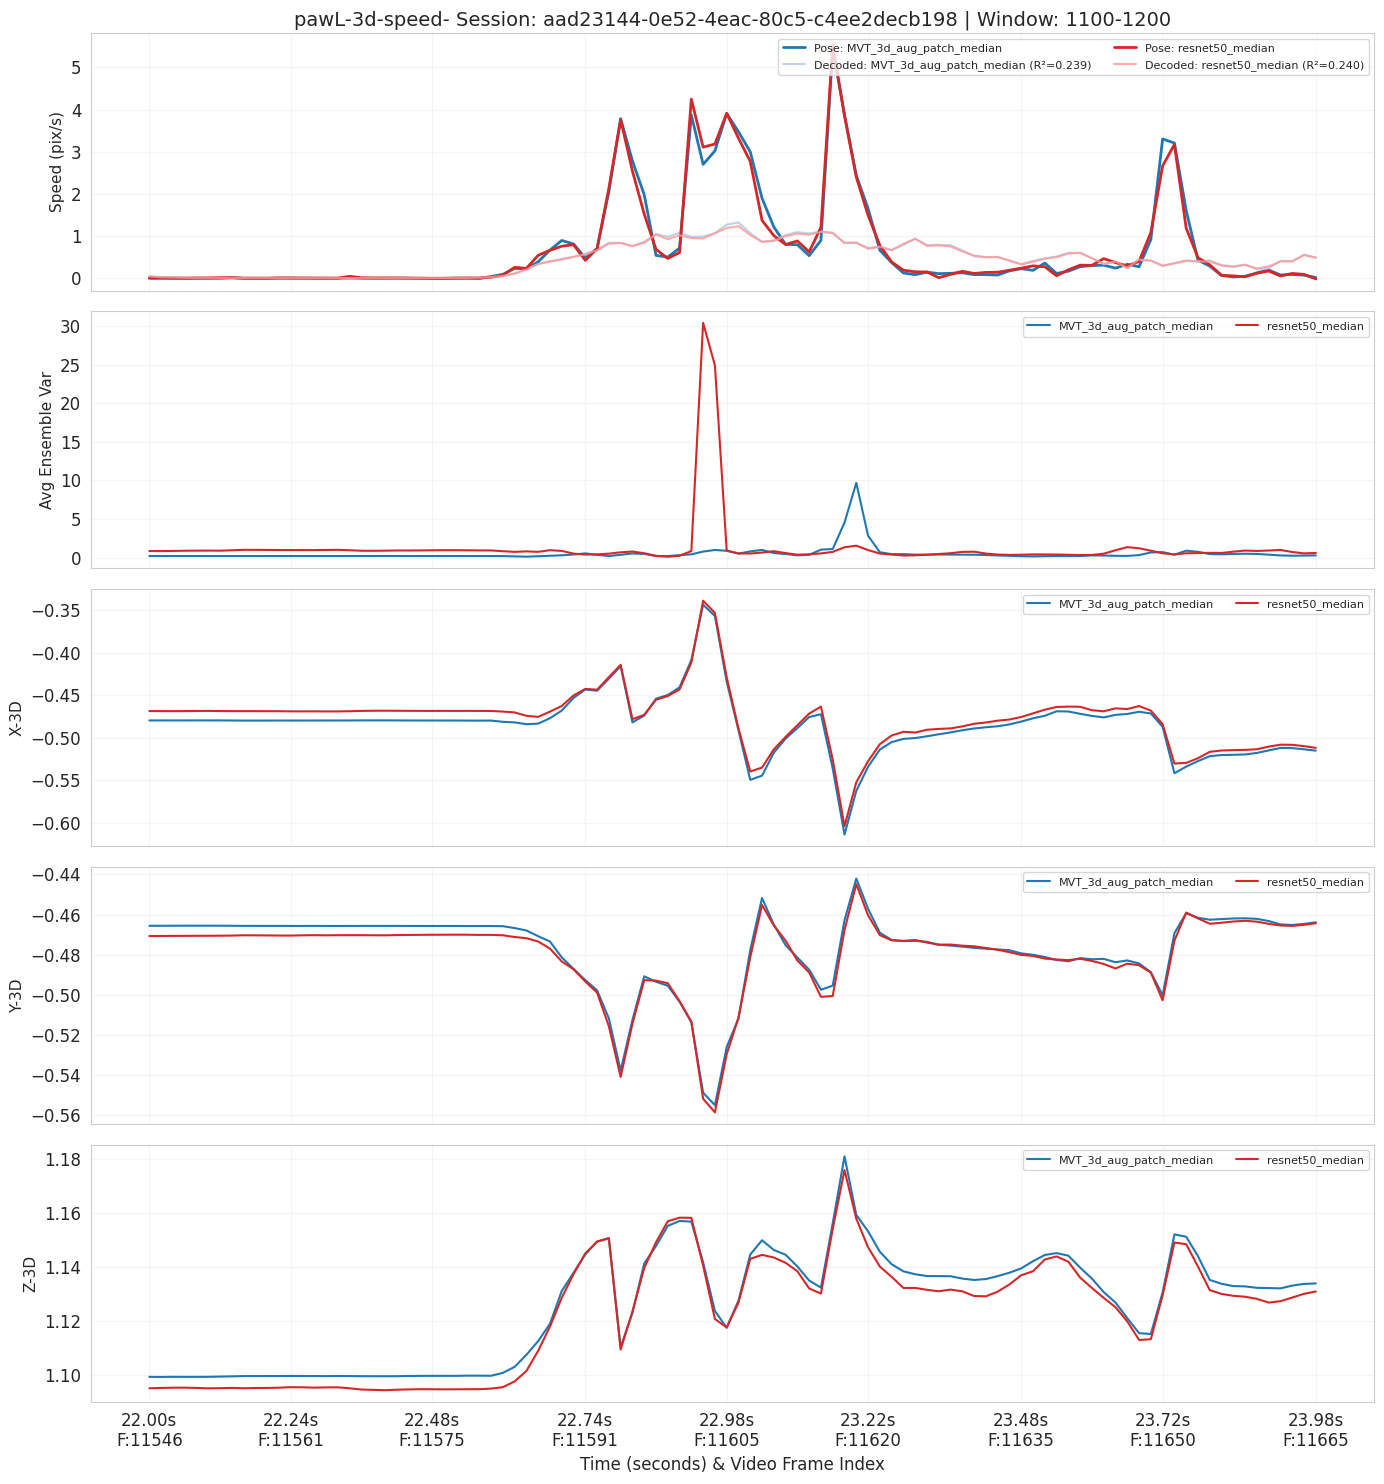

In [136]:
plots_to_show = ['speed','avg_var','x_3d', 'y_3d', 'z_3d']

plot_pose_results(results, pose_models, colors, eid, plots_to_show, start_time=1100, end_time=1200)

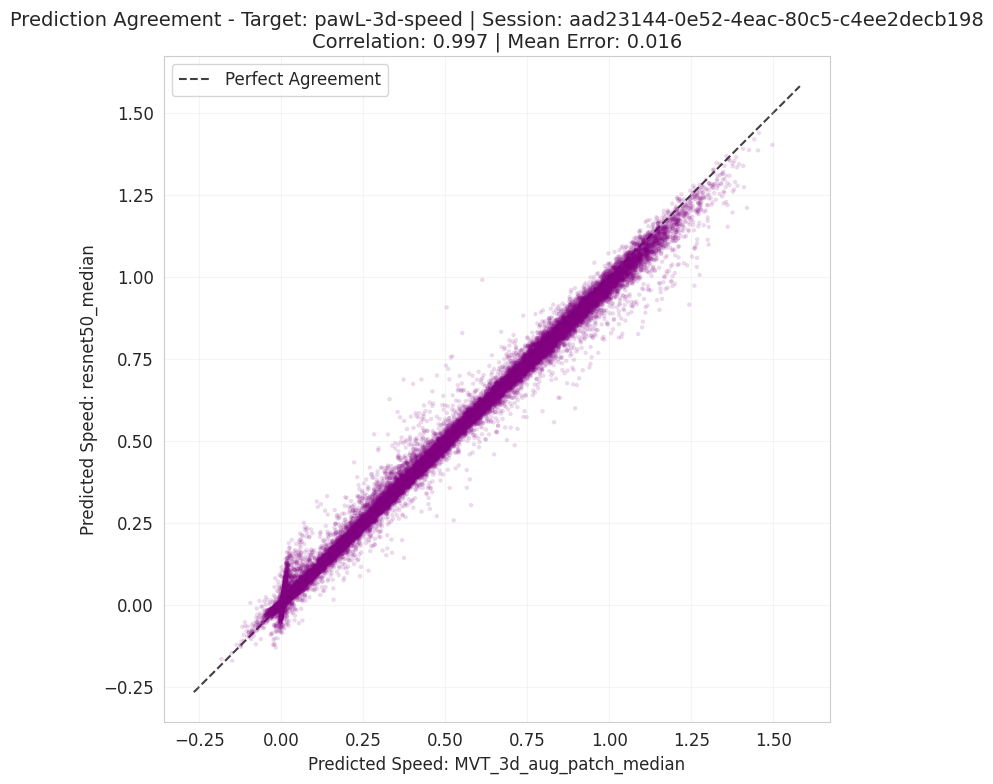

In [105]:
def plot_prediction_agreement(results, pose_models,target=target):
    """
    Creates a scatter plot comparing the neural predictions of two models.
    """
    if len(pose_models) < 2:
        print("Need at least two models to compare.")
        return

    # Get the flattened predictions for the first two models
    m1, m2 = pose_models[0], pose_models[1]
    pred1 = results[m1]['pred_flattened']
    pred2 = results[m2]['pred_flattened']
    
    # Ensure they are the same length (they should be for the same session)
    min_len = min(len(pred1), len(pred2))
    pred1, pred2 = pred1[:min_len], pred2[:min_len]

    # Calculate disagreement metrics
    correlation = np.corrcoef(pred1, pred2)[0, 1]
    mean_diff = np.mean(np.abs(pred1 - pred2))
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Scatter plot with high transparency to see density
    ax.scatter(pred1, pred2, alpha=0.15, s=10, color='purple', edgecolors='none')
    
    # Add identity line (y=x) - where they would perfectly agree
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),
        np.max([ax.get_xlim(), ax.get_ylim()]),
    ]
    ax.plot(lims, lims, 'k--', alpha=0.75, zorder=0, label='Perfect Agreement')
    
    # Formatting
    ax.set_xlabel(f"Predicted Speed: {m1}", fontsize=12)
    ax.set_ylabel(f"Predicted Speed: {m2}", fontsize=12)
    target_without = target.replace("lightning-pose-", "")
    ax.set_title(f"Prediction Agreement - Target: {target_without} | Session: {eid}\nCorrelation: {correlation:.3f} | Mean Error: {mean_diff:.3f}", fontsize=14)
    
    ax.grid(True, alpha=0.2)
    ax.set_aspect('equal')
    ax.legend()
    
    plt.tight_layout()
    plt.show()  # Explicitly show the plot to prevent duplicate display
    return fig

# Call the function
fig = plot_prediction_agreement(results, pose_models)

In [106]:
from sklearn.metrics import mean_squared_error, r2_score

def analyze_disagreement_performance(results, pose_models, percentile=90, target=target):
    """
    Identifies frames where predictions differ most and evaluates 
    decoding performance on those specific frames.
    """
    m1, m2 = pose_models[0], pose_models[1]
    
    # 1. Get predictions and ground truths
    p1, p2 = results[m1]['pred_flattened'], results[m2]['pred_flattened']
    y1, y2 = results[m1]['y_flattened'], results[m2]['y_flattened']
    
    # 2. Compute absolute disagreement between the two NEURAL predictions
    disagreement = np.abs(p1 - p2)
    
    # 3. Define "High Disagreement" frames (e.g., the top 10% most different)
    threshold = np.percentile(disagreement, percentile)
    mask = disagreement >= threshold
    
    num_frames = np.sum(mask)
    print(f"Analyzing {num_frames} frames of high disagreement (Top {100-percentile}%)...")
    target_without = target.replace("lightning-pose-", "")
    print(f"Target: {target_without} | Session: {eid}")
    print(f"Disagreement threshold: {threshold:.3f} pix/s")
    
    # 4. Compute metrics ONLY on these frames
    metrics = {}
    for m in [m1, m2]:
        pred_subset = results[m]['pred_flattened'][mask]
        truth_subset = results[m]['y_flattened'][mask]
        
        mse = mean_squared_error(truth_subset, pred_subset)
        r2 = r2_score(truth_subset, pred_subset)
        corr = np.corrcoef(truth_subset, pred_subset)[0, 1]
        
        metrics[m] = {'mse': mse, 'r2': r2, 'corr': corr}
    
    # 5. Print Comparison
    print(f"\n{'Model':<25} | {'MSE (Loss)':<12} | {'R²':<10} | {'Correlation'}")
    print("-" * 65)
    for m in [m1, m2]:
        met = metrics[m]
        print(f"{m:<25} | {met['mse']:<12.4f} | {met['r2']:<10.3f} | {met['corr']:.3f}")
        
    return mask, metrics

# Run the analysis
disagreement_mask, disagreement_metrics = analyze_disagreement_performance(results, pose_models)

Analyzing 3720 frames of high disagreement (Top 10%)...
Target: pawL-3d-speed | Session: aad23144-0e52-4eac-80c5-c4ee2decb198
Disagreement threshold: 0.039 pix/s

Model                     | MSE (Loss)   | R²         | Correlation
-----------------------------------------------------------------
MVT_3d_aug_patch_median   | 0.7818       | 0.189      | 0.435
resnet50_median           | 0.7124       | 0.194      | 0.444


# This code evaluates each model against its own internal "difficulty" (ensemble variance), which means that the 10th percentile" for Model A might have included different frames than the "10th percentile" for Model B.

 the bin r^2 for model MVT_3d_aug_patch_median is -0.3171952218165657
 the bin r^2 for model MVT_3d_aug_patch_median is 0.07764832944912281
 the bin r^2 for model MVT_3d_aug_patch_median is 0.16887705073932013
 the bin r^2 for model MVT_3d_aug_patch_median is 0.21485591312204422
 the bin r^2 for model MVT_3d_aug_patch_median is 0.2400856504522928
 the bin r^2 for model MVT_3d_aug_patch_median is 0.23649682083220214
 the bin r^2 for model MVT_3d_aug_patch_median is 0.27203002815386945
 the bin r^2 for model MVT_3d_aug_patch_median is 0.2861147087576621
 the bin r^2 for model MVT_3d_aug_patch_median is 0.29905130822470616
 the bin r^2 for model MVT_3d_aug_patch_median is 0.15949909167916676
 the bin r^2 for model resnet50_median is -0.10045659898992887
 the bin r^2 for model resnet50_median is 0.1948697963457977
 the bin r^2 for model resnet50_median is 0.2345147770761956
 the bin r^2 for model resnet50_median is 0.2528746655887182
 the bin r^2 for model resnet50_median is 0.261715769498

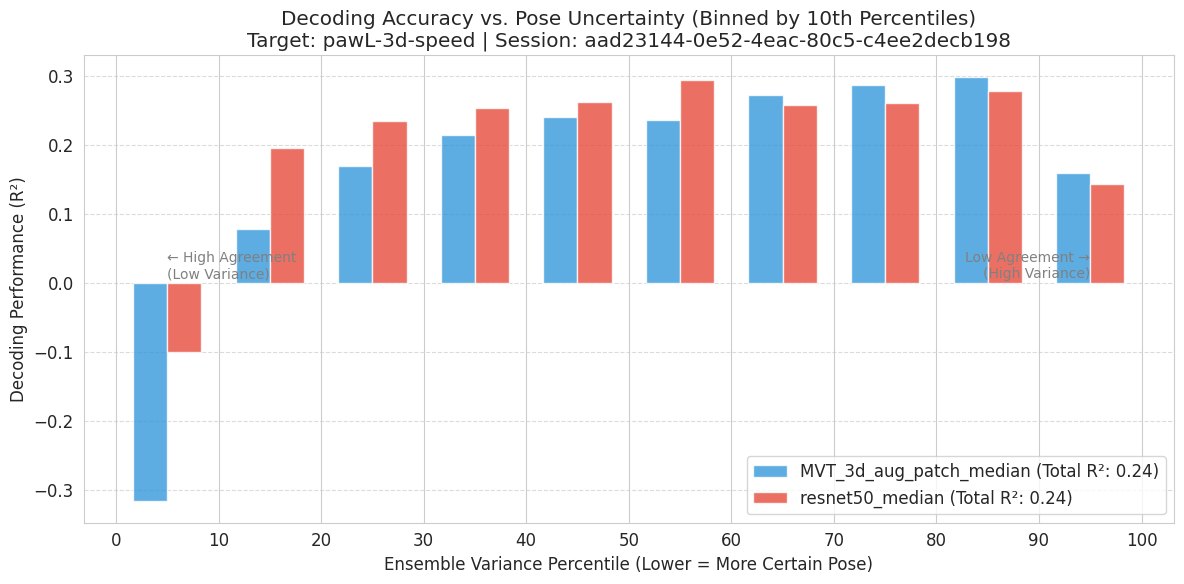

In [107]:

def plot_performance_by_variance_percentiles(results, pose_models, n_bins=10):
    """
    Bins the data by ensemble variance percentiles and computes R^2 for each bin.
    """
    plt.figure(figsize=(12, 6))
    
    # Define the percentile edges (0, 10, 20, ..., 100)
    percentiles = np.linspace(0, 100, n_bins + 1)
    bin_centers = (percentiles[:-1] + percentiles[1:]) / 2
    
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f1c40f']
    
    for i, model_name in enumerate(pose_models):
        res = results[model_name]
        
        # Get flattened ground truth, predictions, and variance
        y_true = res['y_flattened']
        y_pred = res['pred_flattened']
        
        # Use the unified average variance we calculated during loading
        if 'avg_ens_var_flattened' not in res:
            print(f"Skipping {model_name}: No ensemble variance found.")
            continue
            
        var = res['avg_ens_var_flattened']
        
        # Calculate percentile thresholds for this model's variance
        thresholds = np.percentile(var, percentiles)
        
        bin_r2s = []
        bin_counts = []
        
        for j in range(n_bins):
            # Create mask for frames in this variance percentile bin
            lower = thresholds[j]
            upper = thresholds[j+1]
            
            # Handle the last bin inclusive edge
            if j == n_bins - 1:
                mask = (var >= lower) & (var <= upper)
            else:
                mask = (var >= lower) & (var < upper)
            
            if np.sum(mask) > 10:  # Need enough points for a stable R2
                r2 = r2_score(y_true[mask], y_pred[mask])
                bin_r2s.append(r2)
            else:
                bin_r2s.append(0)
            bin_counts.append(np.sum(mask))
            print(f" the bin r^2 for model {model_name} is {r2}")

            
        # Plotting the bars
        # Offsetting bars slightly so they don't overlap if comparing multiple models
        width = 10 / (len(pose_models) + 1)
        offset = (i - len(pose_models)/2 + 0.5) * width
        
        plt.bar(bin_centers + offset, bin_r2s, width=width, 
                label=f"{model_name} (Total R²: {res['r2']:.2f})", 
                color=colors[i % len(colors)], alpha=0.8)

    plt.xlabel('Ensemble Variance Percentile (Lower = More Certain Pose)')
    plt.ylabel('Decoding Performance (R²)')
    target_without = target.replace("lightning-pose-", "")
    plt.title(f'Decoding Accuracy vs. Pose Uncertainty (Binned by 10th Percentiles)\nTarget: {target_without} | Session: {eid}')
    plt.xticks(percentiles)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add info about what low/high percentiles mean
    plt.text(5, plt.ylim()[1]*0.02, "← High Agreement\n(Low Variance)", ha='left', fontsize=10, color='gray')
    plt.text(95, plt.ylim()[1]*0.02, "Low Agreement →\n(High Variance)", ha='right', fontsize=10, color='gray')

    plt.tight_layout()
    plt.show()

# Run the analysis
plot_performance_by_variance_percentiles(results, pose_models)

# To compare them fairly on the exact same frames, we should use a shared uncertainty scale. we do this by averging the ensemble variances of both pose models to define a single "global difficulty" for every frame. Same frames for all of the precentiles.

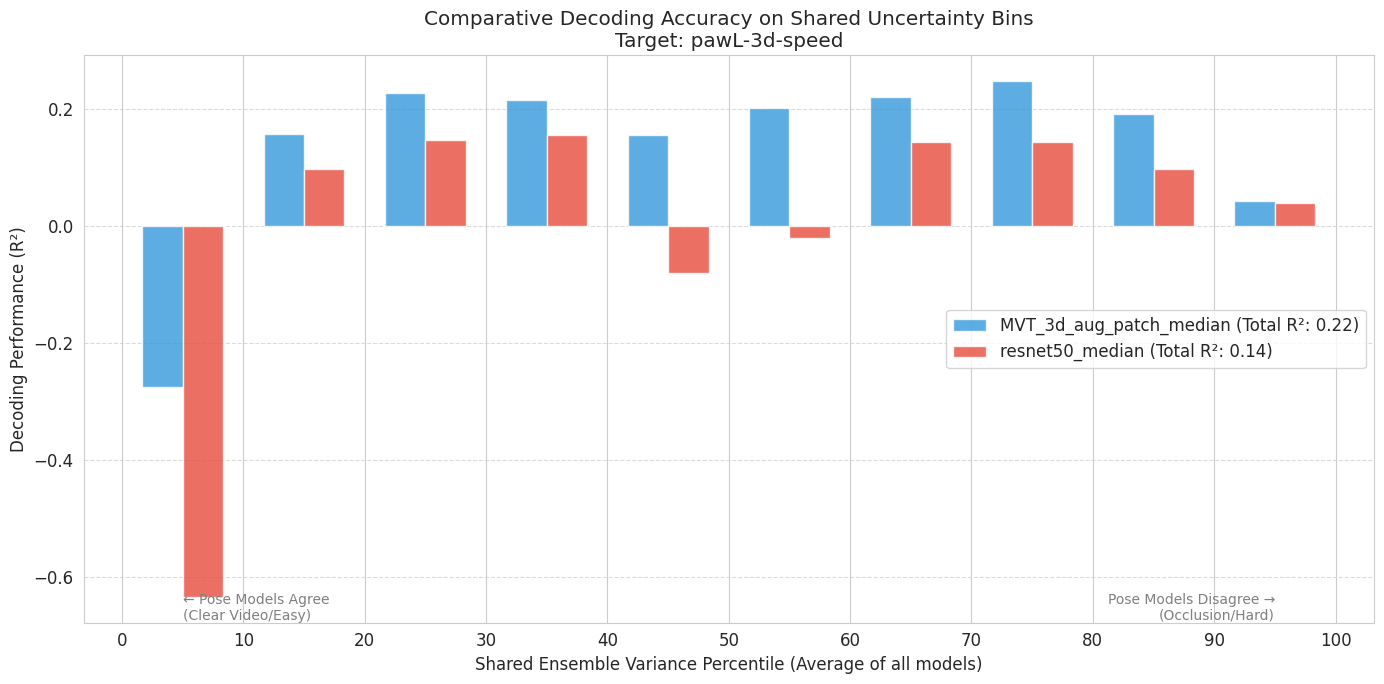

In [65]:
def plot_performance_by_shared_variance(results, pose_models, n_bins=10):
    """
    Computes a shared uncertainty scale by averaging variances from all models,
    then evaluates each model on the exact same frames per bin.
    """
    # 1. Ensure models are aligned and compute shared variance
    # (Assuming all models have the same number of frames from the same CV splits)
    all_vars = []
    for m in pose_models:
        if 'avg_ens_var_flattened' in results[m]:
            all_vars.append(results[m]['avg_ens_var_flattened'])
    
    if not all_vars:
        print("Error: No ensemble variance found in results.")
        return

    # Compute the average variance across all pose models for every frame
    shared_var = np.mean(all_vars, axis=0)
    # shared_var = np.max(all_vars, axis=0)
    
    # 2. Define shared percentile thresholds based on this global scale
    percentiles = np.linspace(0, 100, n_bins + 1)
    thresholds = np.percentile(shared_var, percentiles)
    bin_centers = (percentiles[:-1] + percentiles[1:]) / 2
    
    # 3. Plotting
    plt.figure(figsize=(14, 7))
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f1c40f']
    width = 10 / (len(pose_models) + 1)
    
    for i, model_name in enumerate(pose_models):
        res = results[model_name]
        y_true = res['y_flattened']
        y_pred = res['pred_flattened']
        
        bin_r2s = []
        
        for j in range(n_bins):
            # Use the SHARED_VAR to create the mask (same frames for all models)
            lower, upper = thresholds[j], thresholds[j+1]
            if j == n_bins - 1:
                mask = (shared_var >= lower) & (shared_var <= upper)
            else:
                mask = (shared_var >= lower) & (shared_var < upper)
            
            if np.sum(mask) > 10:
                r2 = r2_score(y_true[mask], y_pred[mask])
                bin_r2s.append(r2)
            else:
                bin_r2s.append(0)
        
        offset = (i - len(pose_models)/2 + 0.5) * width
        plt.bar(bin_centers + offset, bin_r2s, width=width, 
                label=f"{model_name} (Total R²: {res['r2']:.2f})", 
                color=colors[i % len(colors)], alpha=0.8)

    plt.xlabel('Shared Ensemble Variance Percentile (Average of all models)')
    plt.ylabel('Decoding Performance (R²)')
    target_without = target.replace("lightning-pose-", "")
    plt.title(f'Comparative Decoding Accuracy on Shared Uncertainty Bins\nTarget: {target_without}')
    plt.xticks(percentiles)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.text(5, plt.ylim()[0], "← Pose Models Agree\n(Clear Video/Easy)", ha='left', va='bottom', fontsize=10, color='gray')
    plt.text(95, plt.ylim()[0], "Pose Models Disagree →\n(Occlusion/Hard)", ha='right', va='bottom', fontsize=10, color='gray')

    plt.tight_layout()
    plt.show()

# Run the updated analysis
plot_performance_by_shared_variance(results, pose_models)

In [89]:
import pandas as pd

# 1. Load Alignment and Timestamps
common_data_path = Path("/media/lenny-aharon/T7/ibl-mouse/ibl-mouse_neural-activity/ibl_aligned") / eid
alignment_info = np.load(common_data_path / "alignment_info.npy", allow_pickle=True).item()
trial_intervals = alignment_info["trial_intervals"] 

timestamp_file = Path("/media/lenny-aharon/T7/ibl-mouse/timestamps") / f"_ibl_leftCamera.times.{eid}.npy"
frame_times = np.load(timestamp_file)

# 2. Get the trials in the order they appear in your plot
orig_trial_ids = results[pose_models[0]]['test_original_trial_ids']

mapping_list = []

for i, orig_id in enumerate(orig_trial_ids):
    # Get the start and end time for this 2-second trial
    t_start, t_end = trial_intervals[orig_id]
    
    # Find the exact indices in the 100,000 frame video
    raw_frame_start = np.searchsorted(frame_times, t_start, side="left")
    raw_frame_end = np.searchsorted(frame_times, t_end, side="right")
    
    mapping_list.append({
        'Plot_Trial_Index': i,
        'Plot_Time_Range': f"{i*2}-{(i+1)*2}s",
        'Session_Trial_ID': orig_id,
        'Video_Frame_Start': raw_frame_start,
        'Video_Frame_End': raw_frame_end,
        'Total_Video_Frames': raw_frame_end - raw_frame_start
    })

# Display as a table
mapping_df = pd.DataFrame(mapping_list)
print(mapping_df.head(10)) # Show first 10 trials

   Plot_Trial_Index Plot_Time_Range  Session_Trial_ID  Video_Frame_Start  \
0                 0            0-2s                 9               3398   
1                 1            2-4s                46              11969   
2                 2            4-6s                36               9966   
3                 3            6-8s               341              80932   
4                 4           8-10s               299              70857   
5                 5          10-12s               412              96972   
6                 6          12-14s                60              15437   
7                 7          14-16s               295              69962   
8                 8          16-18s               269              64183   
9                 9          18-20s               125              30399   

   Video_Frame_End  Total_Video_Frames  
0             3520                 122  
1            12091                 122  
2            10088                 122  

# This is Good until here

Zoomed In version

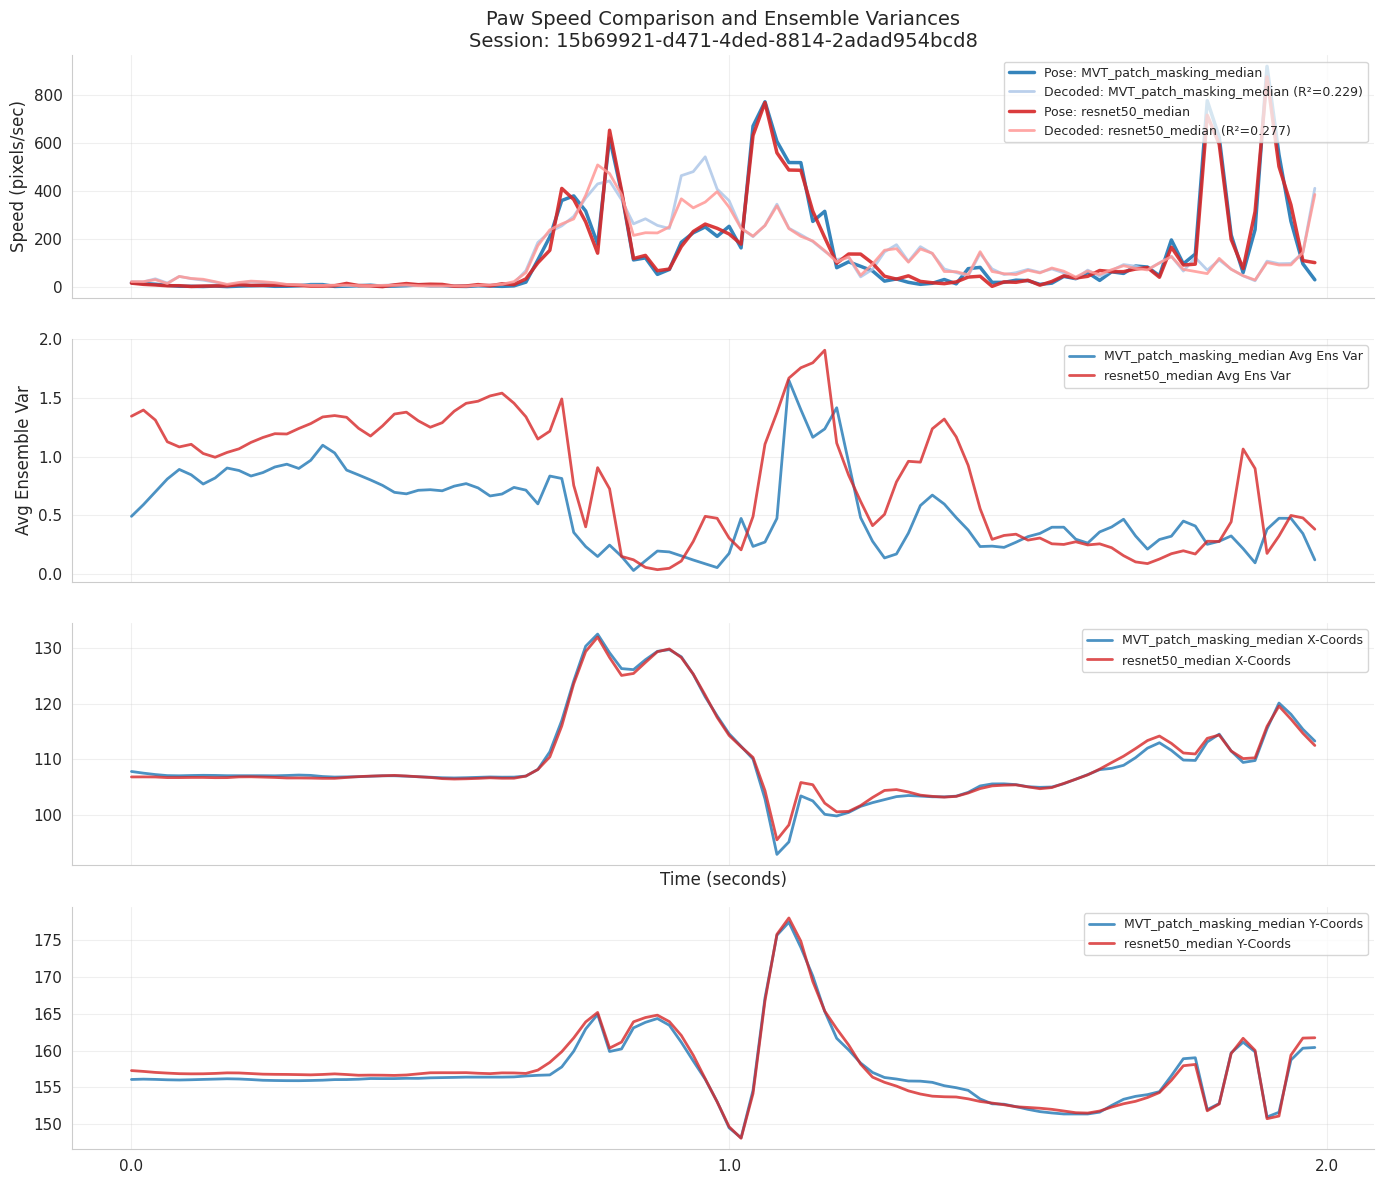

In [27]:
# Plot the continuous paw speed traces and ensemble variances
start_time = 0
end_point = 100
end_time = min(end_point, len(results[pose_models[0]]['y_flattened']))

# Create 3 subplots: Speed, X-Variance, Y-Variance
fig, ax = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Plot traces for each pose model
for pose_model in pose_models:
    # 1. Plot Speed Traces (Top Subplot)
    y_flat = results[pose_model]['y_flattened']
    pred_flat = results[pose_model]['pred_flattened']
    r2_val = results[pose_model]['r2']
    
    ax[0].plot(y_flat[start_time:end_time], 
               color=colors[pose_model]['pose'], 
               linewidth=2.5, 
               label=f"Pose: {pose_model}", 
               alpha=0.9)
    
    ax[0].plot(pred_flat[start_time:end_time], 
               color=colors[pose_model]['decoded'], 
               linewidth=2, 
               label=f"Decoded: {pose_model} (R²={r2_val:.3f})", 
               alpha=0.85)
    
    # 2. Plot Average Ensemble Variance (Middle Subplot)
    if (results[pose_model]['ens_x_flattened'] is not None and 
        results[pose_model]['ens_y_flattened'] is not None):
        # Calculate average of X and Y ensemble variances
        avg_ens_var = (results[pose_model]['ens_x_flattened'] + 
                       results[pose_model]['ens_y_flattened']) / 2
        ax[1].plot(avg_ens_var[start_time:end_time], 
                   color=colors[pose_model]['pose'], 
                   linewidth=2, 
                   label=f"{pose_model} Avg Ens Var", 
                   alpha=0.8)
    # 4. Plot X Coordinates (Bottom Subplot)
    if results[pose_model]['x_coords_flattened'] is not None:
        ax[2].plot(results[pose_model]['x_coords_flattened'][start_time:end_time], 
                   color=colors[pose_model]['pose'], 
                   linewidth=2, 
                   label=f"{pose_model} X-Coords", 
                   alpha=0.8)
    # 5. Plot Y Coordinates (Bottom Subplot)
    if results[pose_model]['y_coords_flattened'] is not None:
        ax[3].plot(results[pose_model]['y_coords_flattened'][start_time:end_time], 
                   color=colors[pose_model]['pose'], 
                   linewidth=2, 
                   label=f"{pose_model} Y-Coords", 
                   alpha=0.8)

# Formatting for all subplots
ax[0].set_ylabel("Speed (pixels/sec)", fontsize=12)
ax[0].set_title(f"Paw Speed Comparison and Ensemble Variances\nSession: {eid}", fontsize=14)
ax[1].set_ylabel("Avg Ensemble Var", fontsize=12)
ax[2].set_xlabel("Time (seconds)", fontsize=12)

for a in ax:
    a.legend(fontsize=9, loc='upper right', framealpha=0.8)
    a.grid(True, alpha=0.3)
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.tick_params(axis='both', labelsize=11)

# Convert x-axis to time in seconds (aligned across all)
# xticks = [0, 100, 200, 300, 400, 500, 600, 700, 800]
# for xticks I want to take the length that i have and divide by 4 
xticks = [0, 50, 100]
xticklabels = [f"{x * 0.02:.1f}" for x in xticks]
ax[2].set_xticks(xticks)
ax[2].set_xticklabels(xticklabels)

plt.tight_layout()
plt.show()

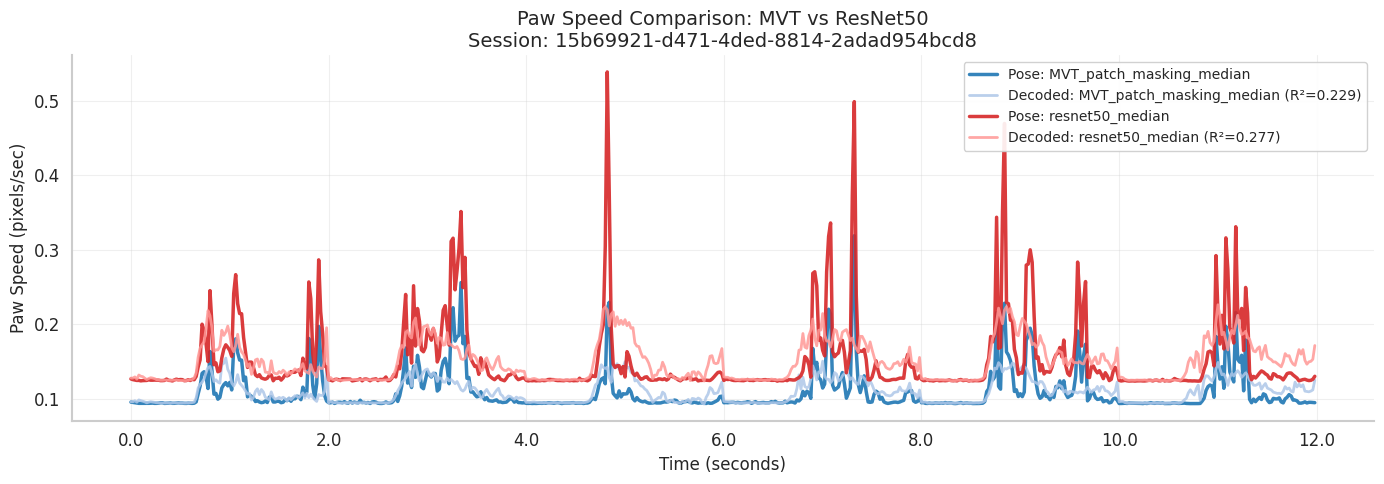

In [ ]:
# # Plot the continuous paw speed traces
# start_time = 0
# end_time = min(600, len(results[pose_models[0]]['y_flattened']))

# fig, ax = plt.subplots(1, 1, figsize=(14, 5))

# # Plot traces for each pose model
# for pose_model in pose_models:
#     y_flat = results[pose_model]['y_flattened']
#     pred_flat = results[pose_model]['pred_flattened']
#     r2_val = results[pose_model]['r2']
    
#     # Pose model trace (ground truth) - darker, thicker
#     ax.plot(y_flat[start_time:end_time], 
#             color=colors[pose_model]['pose'], 
#             linewidth=2.5, 
#             label=f"Pose: {pose_model}", 
#             alpha=0.9)
    
#     # Decoded prediction - lighter, slightly thinner
#     ax.plot(pred_flat[start_time:end_time], 
#             color=colors[pose_model]['decoded'], 
#             linewidth=2, 
#             label=f"Decoded: {pose_model} (R²={r2_val:.3f})", 
#             alpha=0.85,
#             linestyle='-')

# # Formatting
# ax.set_ylabel("Paw Speed (pixels/sec)", fontsize=12)
# ax.set_xlabel("Time (seconds)", fontsize=12)
# ax.set_title(f"Paw Speed Comparison: MVT vs ResNet50\nSession: {eid}", fontsize=14)
# ax.legend(fontsize=10, loc='upper right', framealpha=0.9)
# ax.grid(True, alpha=0.3)

# # Remove top and right spines
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_linewidth(1.5)
# ax.spines['bottom'].set_linewidth(1.5)
# ax.tick_params(axis='both', width=1.5, length=5, labelsize=12)

# # Convert x-axis to time in seconds
# xticks = [0, 100, 200, 300, 400, 500, 600]
# xticklabels = [f"{x * 0.02:.1f}" for x in xticks]
# ax.set_xticks(xticks)
# ax.set_xticklabels(xticklabels)

# plt.tight_layout()
# # plt.savefig('paw_speed_comparison.png', dpi=400, bbox_inches='tight')
# plt.show()

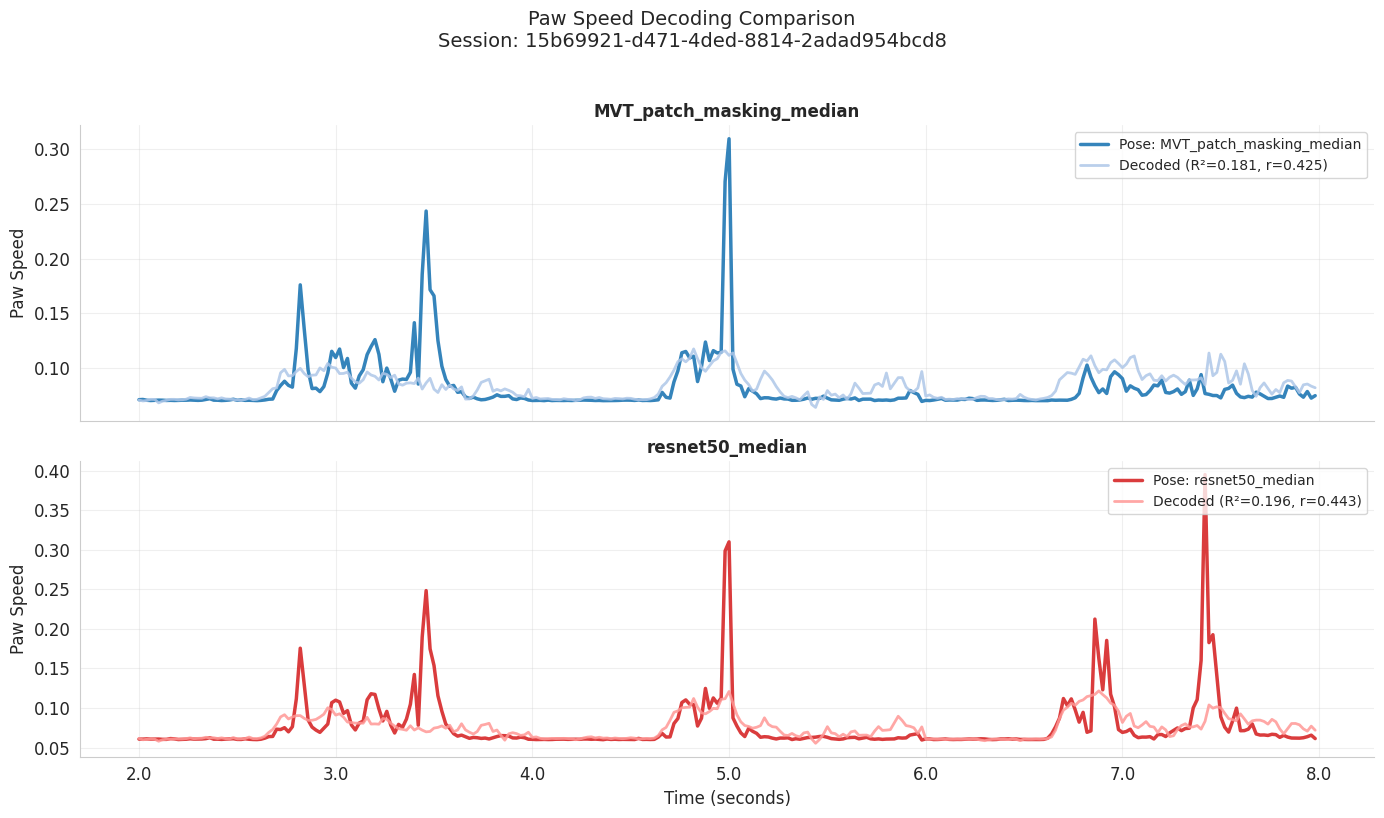

In [16]:
# Alternative: Zoomed-in view for better visibility of differences
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Shorter time window to see details
zoom_start = 100
zoom_end = 400

for idx, pose_model in enumerate(pose_models):
    ax = axes[idx]
    y_flat = results[pose_model]['y_flattened']
    pred_flat = results[pose_model]['pred_flattened']
    r2_val = results[pose_model]['r2']
    corr_val = results[pose_model]['correlation']
    
    # Pose model trace (ground truth)
    ax.plot(range(zoom_start, zoom_end), 
            y_flat[zoom_start:zoom_end], 
            color=colors[pose_model]['pose'], 
            linewidth=2.5, 
            label=f"Pose: {pose_model}", 
            alpha=0.9)
    
    # Decoded prediction
    ax.plot(range(zoom_start, zoom_end), 
            pred_flat[zoom_start:zoom_end], 
            color=colors[pose_model]['decoded'], 
            linewidth=2, 
            label=f"Decoded (R²={r2_val:.3f}, r={corr_val:.3f})", 
            alpha=0.85)
    
    ax.set_ylabel("Paw Speed", fontsize=12)
    ax.set_title(f"{pose_model}", fontsize=12, fontweight='bold')
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[1].set_xlabel("Time (seconds)", fontsize=12)

# Convert x-axis to time in seconds
xticks = [100, 150, 200, 250, 300, 350, 400]
xticklabels = [f"{x * 0.02:.1f}" for x in xticks]
axes[1].set_xticks(xticks)
axes[1].set_xticklabels(xticklabels)

plt.suptitle(f"Paw Speed Decoding Comparison\nSession: {eid}", fontsize=14, y=1.02)
plt.tight_layout()
# plt.savefig('paw_speed_comparison_subplots.png', dpi=400, bbox_inches='tight')
plt.show()

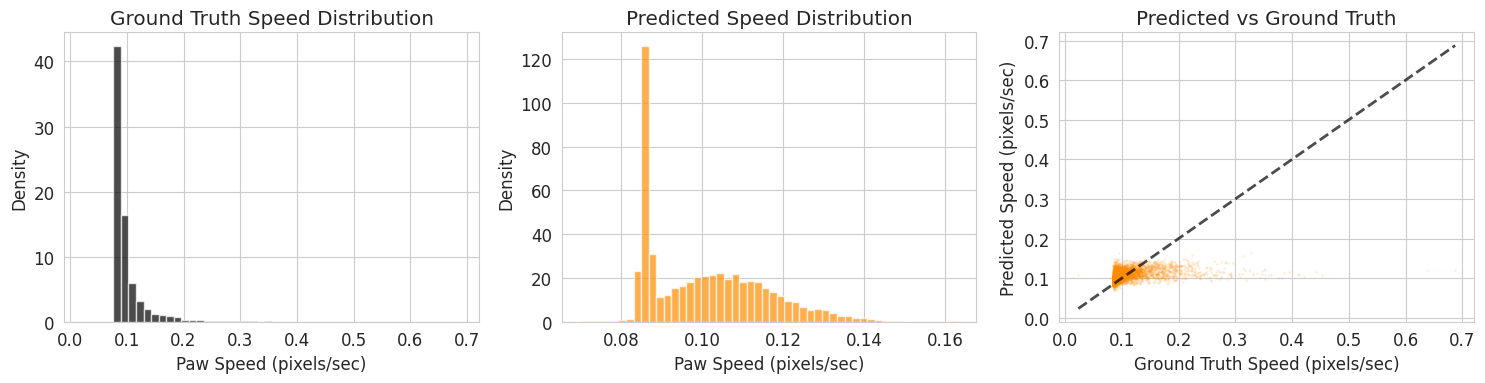

In [21]:
# Additional analysis: Plot distribution of speeds
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution of ground truth speeds
axes[0].hist(y_flattened, bins=50, alpha=0.7, color='black', density=True)
axes[0].set_title('Ground Truth Speed Distribution')
axes[0].set_xlabel('Paw Speed (pixels/sec)')
axes[0].set_ylabel('Density')

# Distribution of predicted speeds
axes[1].hist(pred_flattened, bins=50, alpha=0.7, color='darkorange', density=True)
axes[1].set_title('Predicted Speed Distribution')
axes[1].set_xlabel('Paw Speed (pixels/sec)')
axes[1].set_ylabel('Density')

# Scatter plot: predicted vs ground truth
axes[2].scatter(y_flattened, pred_flattened, alpha=0.1, s=1, color='darkorange')
axes[2].plot([y_flattened.min(), y_flattened.max()], [y_flattened.min(), y_flattened.max()], 
             'k--', linewidth=2, alpha=0.7)
axes[2].set_title('Predicted vs Ground Truth')
axes[2].set_xlabel('Ground Truth Speed (pixels/sec)')
axes[2].set_ylabel('Predicted Speed (pixels/sec)')

plt.tight_layout()
plt.savefig('paw_speed_analysis.png', dpi=400, bbox_inches='tight')
plt.show()

# Running Analysis for all seeds 

In [10]:
eids = [
    "5c0c560e-9e1f-45e9-b66e-e4ee7855be84",
    "15b69921-d471-4ded-8814-2adad954bcd8",
    "15763234-d21e-491f-a01b-1238eb96d389",
    "aad23144-0e52-4eac-80c5-c4ee2decb198",
    "9b528ad0-4599-4a55-9148-96cc1d93fb24",
]

In [12]:
# Store results for all sessions and pose models
all_results = []

for eid in eids:
    print(f"\n{'='*60}")
    print(f"Session: {eid}")
    print(f"{'='*60}")
    
    for pose_model in pose_models:
        results_path = f"{base_path}/{eid}/{target}/{pose_model}/{model}/all/{eid}_cv.npy"
        
        try:
            # Load the data
            data = np.load(results_path, allow_pickle=True).item()
            
            # Extract data
            test_y = data['all_test_y']
            test_pred = data['all_test_pred']
            test_metric = data['overall_metric']
            
            # Flatten for continuous traces
            y_flattened = test_y.flatten()
            pred_flattened = test_pred.flatten()
            
            # Calculate metrics
            correlation = np.corrcoef(y_flattened, pred_flattened)[0, 1]
            r2 = r2_score(y_flattened, pred_flattened)
            mse = mean_squared_error(y_flattened, pred_flattened)
            
            # Store results
            all_results.append({
                'eid': eid,
                'eid_short': eid[:8],  # Short version for plotting
                'pose_model': pose_model,
                'test_metric': test_metric,
                'r2': r2,
                'mse': mse,
                'correlation': correlation,
                'n_trials': test_y.shape[0]
            })
            
            print(f"  {pose_model}: R²={r2:.3f}, Corr={correlation:.3f}")
            
        except FileNotFoundError:
            print(f"  {pose_model}: FILE NOT FOUND")
        except Exception as e:
            print(f"  {pose_model}: ERROR - {e}")

# Convert to DataFrame for easier analysis
df = pd.DataFrame(all_results)
print(f"\n{'='*60}")
print("RESULTS DATAFRAME")
print(f"{'='*60}")
print(df)


Session: 5c0c560e-9e1f-45e9-b66e-e4ee7855be84
  MVT_patch_masking_0: R²=0.319, Corr=0.565
  resnet50_0: R²=0.264, Corr=0.514

Session: 15b69921-d471-4ded-8814-2adad954bcd8
  MVT_patch_masking_0: R²=0.174, Corr=0.417
  resnet50_0: R²=0.130, Corr=0.361

Session: 15763234-d21e-491f-a01b-1238eb96d389
  MVT_patch_masking_0: R²=0.120, Corr=0.348
  resnet50_0: R²=0.231, Corr=0.484

Session: aad23144-0e52-4eac-80c5-c4ee2decb198
  MVT_patch_masking_0: R²=0.064, Corr=0.252
  resnet50_0: R²=0.033, Corr=0.185

Session: 9b528ad0-4599-4a55-9148-96cc1d93fb24
  MVT_patch_masking_0: R²=0.174, Corr=0.418
  resnet50_0: R²=0.253, Corr=0.505

RESULTS DATAFRAME
                                    eid eid_short           pose_model  \
0  5c0c560e-9e1f-45e9-b66e-e4ee7855be84  5c0c560e  MVT_patch_masking_0   
1  5c0c560e-9e1f-45e9-b66e-e4ee7855be84  5c0c560e           resnet50_0   
2  15b69921-d471-4ded-8814-2adad954bcd8  15b69921  MVT_patch_masking_0   
3  15b69921-d471-4ded-8814-2adad954bcd8  15b69921      

In [13]:
# Summary statistics per pose model
print(f"\n{'='*60}")
print("SUMMARY STATISTICS")
print(f"{'='*60}")
summary = df.groupby('pose_model').agg({
    'r2': ['mean', 'std', 'min', 'max'],
    'correlation': ['mean', 'std'],
    'mse': ['mean', 'std']
}).round(3)
print(summary)

# Pivot table for easy comparison
print(f"\n{'='*60}")
print("R² BY SESSION AND MODEL")
print(f"{'='*60}")
pivot = df.pivot(index='eid_short', columns='pose_model', values='r2').round(3)
print(pivot)


SUMMARY STATISTICS
                        r2                      correlation           mse  \
                      mean    std    min    max        mean    std   mean   
pose_model                                                                  
MVT_patch_masking_0  0.170  0.095  0.064  0.319        0.40  0.115  0.001   
resnet50_0           0.182  0.099  0.033  0.264        0.41  0.140  0.001   

                            
                       std  
pose_model                  
MVT_patch_masking_0  0.001  
resnet50_0           0.001  

R² BY SESSION AND MODEL
pose_model  MVT_patch_masking_0  resnet50_0
eid_short                                  
15763234                  0.120       0.231
15b69921                  0.174       0.130
5c0c560e                  0.319       0.264
9b528ad0                  0.174       0.253
aad23144                  0.064       0.033


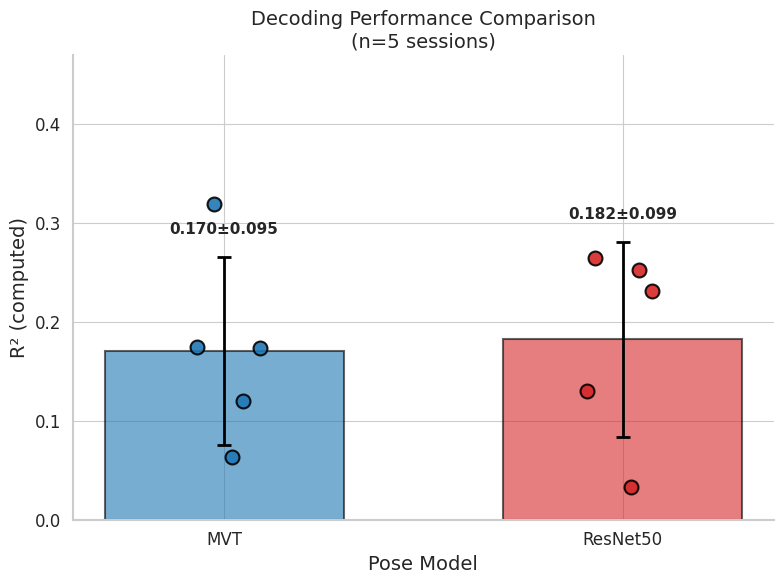

In [14]:
# Bar plot with individual session dots
fig, ax = plt.subplots(figsize=(8, 6))

# Colors matching the previous plots
colors = {
    'MVT_patch_masking_0': '#1f77b4',  # Blue
    'resnet50_0': '#d62728'             # Red
}

# Calculate mean R² for each pose model
mean_r2 = df.groupby('pose_model')['r2'].mean()
std_r2 = df.groupby('pose_model')['r2'].std()

# Bar positions
x_positions = np.arange(len(pose_models))
bar_width = 0.6

# Plot bars (mean values)
bars = ax.bar(x_positions, 
              [mean_r2[pm] for pm in pose_models],
              width=bar_width,
              color=[colors[pm] for pm in pose_models],
              alpha=0.6,
              edgecolor='black',
              linewidth=1.5,
              label='Mean R²')

# Add error bars (standard deviation)
ax.errorbar(x_positions, 
            [mean_r2[pm] for pm in pose_models],
            yerr=[std_r2[pm] for pm in pose_models],
            fmt='none',
            color='black',
            capsize=5,
            capthick=2,
            linewidth=2)

# Add individual session dots
np.random.seed(42)  # For reproducible jitter
for i, pose_model in enumerate(pose_models):
    session_r2 = df[df['pose_model'] == pose_model]['r2'].values
    # Add small jitter for visibility
    jitter = np.random.uniform(-0.1, 0.1, size=len(session_r2))
    ax.scatter(np.full_like(session_r2, i) + jitter, 
               session_r2,
               color=colors[pose_model],
               edgecolor='black',
               s=100,
               zorder=5,
               linewidth=1.5,
               alpha=0.9)

# Formatting
ax.set_xticks(x_positions)
ax.set_xticklabels(['MVT', 'ResNet50'], fontsize=14)
ax.set_ylabel('R² (computed)', fontsize=14)
ax.set_xlabel('Pose Model', fontsize=14)
ax.set_title(f'Decoding Performance Comparison\n(n={len(eids)} sessions)', fontsize=14)

# Add mean values as text on bars
for i, pm in enumerate(pose_models):
    ax.text(i, mean_r2[pm] + std_r2[pm] + 0.02, 
            f'{mean_r2[pm]:.3f}±{std_r2[pm]:.3f}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', width=1.5, length=5, labelsize=12)

# Set y-axis to start from 0
ax.set_ylim(0, max(df['r2']) + 0.15)

plt.tight_layout()
# plt.savefig('r2_comparison_histogram.png', dpi=400, bbox_inches='tight')
plt.show()